# EDA

## Data Cleaning and Outlier Analysis

This will start off my analysis and be the foundation for my report. I first plan on doing some EDA to see how clean the data is and decide what to do with this data.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
raw_df = pd.read_csv("data/raw_data.csv")
raw_df.head(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [4]:
# No missing values:
raw_df.isna().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [5]:
#duplicates:
raw_df.drop(columns="user_id").drop_duplicates() # no duplicates

,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98


In [6]:
raw_df.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

So taking a look at the columns, immediately four jump out as potential variables of interest/ response variables: sleep_duration_hours, sleep_quality_score, stress_level, and mental_fatigue_score

I will do a bit more exploration...

## Univariate Analysis

### Response variables

In [44]:
raw_df.describe()
raw_df.mental_fatigue_score

0         3.57
1         1.91
2         6.05
3         9.92
4         5.99
         ...  
14995    10.00
14996     7.54
14997     7.78
14998     9.98
14999     9.26
Name: mental_fatigue_score, Length: 15000, dtype: float64

So it seems as though the variables that are on a numeric scale were read in as numeric because the unique values are within the interval dictated in the data dictionary. While I had originally assumed that it would be discrete numbers on a scale to use as potential categorical variables, that is no longer an option unless we do some rounding. It depends on what I end up doing with it.

Either way, let's start with some histograms of the four variables.

In [ ]:
#plt.hist(raw_df.sleep_duration_hours) #pretty even-- no tails or drastic imbalances

#plt.hist(raw_df.sleep_quality_score, color="black") 
# #generally expected... but there are class imbalances if we treat it as categorical

#plt.hist(raw_df.mental_fatigue_score) 
# really imbalanced... quite different from sleep quality score, so something else is going on

#plt.hist(raw_df.stress_level)
# # I feel like I just replotted mental_fatigue_score...and while its on a scale of 1-10, 
# # apparently not discrete on that interval 
# really imbalanced, really high, not sure how representative this data is


0        5.31
1        7.36
2        4.50
3        6.68
4        7.57
         ... 
14995    8.91
14996    6.00
14997    7.27
14998    5.70
14999    4.74
Name: sleep_duration_hours, Length: 15000, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1da8c8f2900>,
 'caps': [<matplotlib.lines.Line2D at 0x1da8c8f2ba0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1da8c8f27b0>],
 'medians': [<matplotlib.lines.Line2D at 0x1da8c8f2e40>],
 'fliers': [<matplotlib.lines.Line2D at 0x1da8c8f2f90>],
 'means': []}

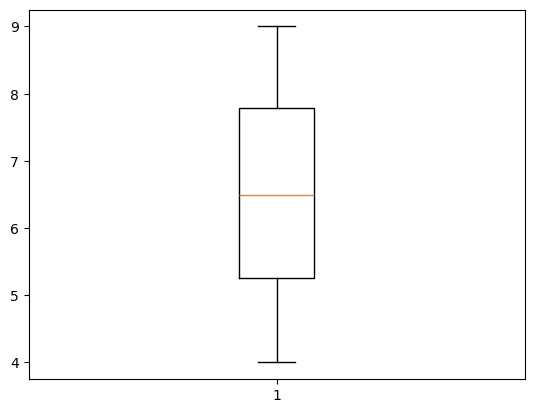

In [9]:
# outliers

# primary concern is sleep duration since the others are scaled...
plt.boxplot(raw_df.sleep_duration_hours)

So... I feel like the first two variables are generally representative of the general population, but maybe a little idealized (no outliers) or at least of what I am aware... the later two seem to be a little biased (or maybe I am the one who is biased)

Now I will take a look at some key predictor variables that may be of interest.

### Predictor Variables:

I have divided the rest of the variables into categories: general demographic info, phone/device usage, and lifestyle. I will look at the distributions of each and whether they have outliers.

In [10]:
# age

#plt.hist(raw_df.age) 
# # slightly peaked on the lower and upper ends, not too bad though

# gender

#plt.hist(raw_df.gender) 
# # the other category is vastly imbalanced, which makes sense, but will have to adjust for it

# occupation

raw_df['occupation'].value_counts() # not too bad...

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

In [11]:
# daily screen time

# plt.hist(raw_df['daily_screen_time_hours']) 
# # very uniform... maybe too uniform? ok range

#phone usage before sleep

# plt.hist(raw_df['phone_usage_before_sleep_minutes']) 
# # also very uniform, ok range since it is in minutes

# notifications per day

# plt.hist(raw_df['notifications_received_per_day']) 
# # pretty even, large range though

In [12]:
# caffeine intake

# plt.hist(raw_df['caffeine_intake_cups']) 
# # discrete increments, ok range, too uniform though 

# physical activity

# plt.hist(raw_df['physical_activity_minutes']) 
# # range is fine, just difference in units that would need to scale

From the univariate analysis of the predictors, most are idealized in terms of ranges and distributions. However, the units of certain variables are different and the scales of the ranges are different. This would need adjustment if we used methods like ridge and lasso.

## Multivariate Analysis

### Correlation

I will first explore the relationships between variables via a correlation heatmap and contingency table

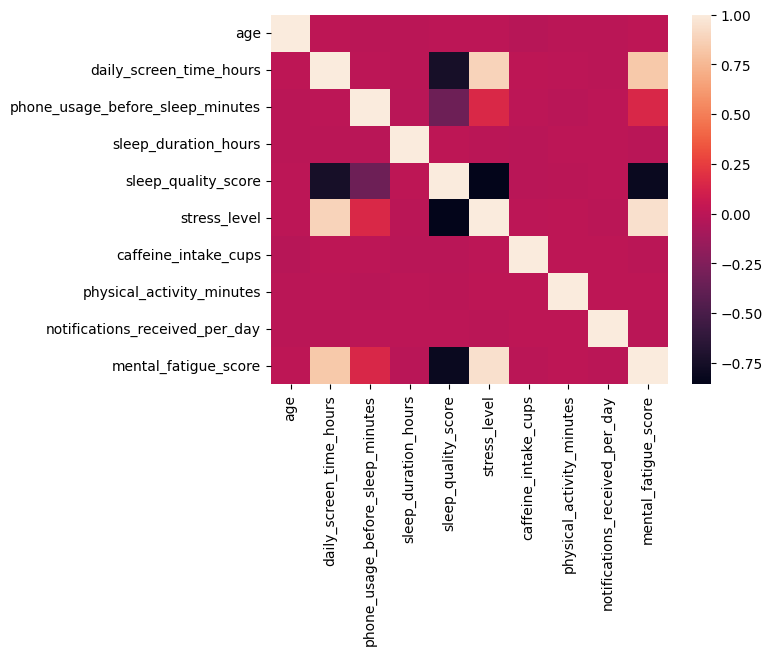

In [33]:
correlation_df = raw_df.select_dtypes(include='number').drop(columns='user_id').corr()


import seaborn as sns

sns.heatmap(correlation_df)
plt.show()

We are definitely seeing interesting relationships for the numeric variables. But now I want to explore some of the categorical variables that we took out for trends.

### Trends

In [54]:
# gender vs stress levels 
raw_df[['gender','stress_level']].groupby("gender").describe()

# gender vs mental fatigue

# gender vs occupation
# gender vs sleep quality
# gender vs sleep duration

stress_level                                                  
              count      mean       std  min   25%   50%    75%   max
gender                                                               
Female       7181.0  6.950724  2.758319  1.0  4.71  7.34   9.99  10.0
Male         7234.0  6.999816  2.742640  1.0  4.78  7.42  10.00  10.0
Other         585.0  7.100650  2.721860  1.0  4.94  7.54  10.00  10.0

In [ ]:
# occupation vs stress levels
# occupaton vs mental fatigue
# occupation vs sleep duration
# occupation vs sleep quality